In [24]:
import numpy as np
import pandas as pd 
import seaborn as sns

In [25]:
poverty = pd.read_csv('HDPulse_data_export.csv',skiprows=3)
poverty

,State,FIPS,Value (Percent),People (Below Poverty),Rank within US (of 52 states)
0,United States,0.0,12.4,40390045.0,NaN
1,Puerto Rico,72001.0,41.6,1340637.0,52.0
2,Mississippi,28000.0,19.1,543697.0,51.0
3,Louisiana,22000.0,18.9,848769.0,50.0
4,New Mexico,35000.0,18.1,375381.0,49.0
5,West Virginia,54000.0,16.6,287660.0,48.0
6,Kentucky,21000.0,16.1,707480.0,47.0
7,Arkansas,5000.0,16.0,471783.0,46.0
8,Alabama,1000.0,15.6,768185.0,45.0
9,Oklahoma,40000.0,15.3,593820.0,44.0


In [26]:
unemployment = pd.read_csv("unemployment.csv",skiprows=3)
poverty = pd.read_csv("poverty.csv",skiprows=3)
income = pd.read_csv("income.csv",skiprows=3)

In [27]:
print(unemployment.columns)
print(poverty.columns)
print(income.columns)

Index(['County', 'FIPS', 'Value (Percent)', 'People (Unemployed)',
       'Rank within US (of 3143 counties)'],
      dtype='object')
Index(['County', 'FIPS', 'Value (Percent)', 'Families (Below Poverty)',
       'Rank within US (of 3143 counties)'],
      dtype='object')
Index(['County', 'FIPS', 'Value (Dollars)',
       'Rank within US (of 3141 counties)'],
      dtype='object')


In [28]:
unemployment = unemployment[unemployment.iloc[:,0].str.contains("County|Parish", na=False)]
poverty = poverty[poverty.iloc[:,0].str.contains("County|Parish", na=False)]
income = income[income.iloc[:,0].str.contains("County|Parish", na=False)]

In [29]:
poverty

,County,FIPS,Value (Percent),Families (Below Poverty),Rank within US (of 3143 counties)
0,"Oglala Lakota County, South Dakota",46102.0,48.8,1101.0,"3,143"
1,"Jackson County, South Dakota",46071.0,38.9,213.0,"3,142"
2,"Todd County, South Dakota",46121.0,38.4,672.0,"3,141"
4,"Dimmit County, Texas",48127.0,36.8,800.0,"3,139"
5,"Corson County, South Dakota",46031.0,35.2,290.0,"3,138"
...,...,...,...,...,...
3138,"Hinsdale County, Colorado",8053.0,0.0,0.0,1
3139,"Hooker County, Nebraska",31091.0,0.0,0.0,1
3140,"Kalawao County, Hawaii",15005.0,0.0,0.0,1
3141,"Kenedy County, Texas",48261.0,0.0,0.0,1


In [30]:
unemployment['FIPS'] = unemployment['FIPS'].astype(str)
poverty['FIPS'] = poverty['FIPS'].astype(str)
income['FIPS'] = income['FIPS'].astype(str)

In [31]:
poverty

,County,FIPS,Value (Percent),Families (Below Poverty),Rank within US (of 3143 counties)
0,"Oglala Lakota County, South Dakota",46102.0,48.8,1101.0,"3,143"
1,"Jackson County, South Dakota",46071.0,38.9,213.0,"3,142"
2,"Todd County, South Dakota",46121.0,38.4,672.0,"3,141"
4,"Dimmit County, Texas",48127.0,36.8,800.0,"3,139"
5,"Corson County, South Dakota",46031.0,35.2,290.0,"3,138"
...,...,...,...,...,...
3138,"Hinsdale County, Colorado",8053.0,0.0,0.0,1
3139,"Hooker County, Nebraska",31091.0,0.0,0.0,1
3140,"Kalawao County, Hawaii",15005.0,0.0,0.0,1
3141,"Kenedy County, Texas",48261.0,0.0,0.0,1


In [32]:

df = unemployment.merge(poverty, on="FIPS")
df = df.merge(income, on="FIPS")
df

,County_x,FIPS,Value (Percent)_x,People (Unemployed),Rank within US (of 3143 counties)_x,County_y,Value (Percent)_y,Families (Below Poverty),Rank within US (of 3143 counties)_y,County,Value (Dollars),Rank within US (of 3141 counties)
0,"Quitman County, Georgia",13239.0,31.1,237.0,"3,143","Quitman County, Georgia",8.9,44.0,"1,520","Quitman County, Georgia","36,838","3,093"
1,"Ziebach County, South Dakota",46137.0,24.2,276.0,"3,142","Ziebach County, South Dakota",34.0,193.0,"3,135","Ziebach County, South Dakota","47,333","2,829"
2,"Corson County, South Dakota",46031.0,23.3,359.0,"3,141","Corson County, South Dakota",35.2,290.0,"3,138","Corson County, South Dakota","43,750","2,957"
3,"Sioux County, North Dakota",38085.0,21.5,291.0,"3,140","Sioux County, North Dakota",35.0,261.0,"3,137","Sioux County, North Dakota","41,676","3,017"
4,"St. Helena Parish, Louisiana",22091.0,21.3,1044.0,"3,139","St. Helena Parish, Louisiana",23.5,536.0,"3,076","St. Helena Parish, Louisiana","50,193","2,671"
...,...,...,...,...,...,...,...,...,...,...,...,...
3066,"McMullen County, Texas",48311.0,0.0,0.0,1,"McMullen County, Texas",12.1,15.0,"2,262","McMullen County, Texas","45,833","2,885"
3067,"McPherson County, Nebraska",31117.0,0.0,0.0,1,"McPherson County, Nebraska",2.7,4.0,41,"McPherson County, Nebraska","61,316","1,787"
3068,"Sully County, South Dakota",46119.0,0.0,0.0,1,"Sully County, South Dakota",3.8,14.0,149,"Sully County, South Dakota","70,250","1,028"
3069,"Terrell County, Texas",48443.0,0.0,0.0,1,"Terrell County, Texas",2.5,6.0,38,"Terrell County, Texas","46,989","2,845"


In [33]:
df = df.rename(columns={
    'Value (Percent)_x': 'unemployment',
    'Value (Percent)_y': 'poverty',
    'Value (Dollars)': 'income'
})
df

,County_x,FIPS,unemployment,People (Unemployed),Rank within US (of 3143 counties)_x,County_y,poverty,Families (Below Poverty),Rank within US (of 3143 counties)_y,County,income,Rank within US (of 3141 counties)
0,"Quitman County, Georgia",13239.0,31.1,237.0,"3,143","Quitman County, Georgia",8.9,44.0,"1,520","Quitman County, Georgia","36,838","3,093"
1,"Ziebach County, South Dakota",46137.0,24.2,276.0,"3,142","Ziebach County, South Dakota",34.0,193.0,"3,135","Ziebach County, South Dakota","47,333","2,829"
2,"Corson County, South Dakota",46031.0,23.3,359.0,"3,141","Corson County, South Dakota",35.2,290.0,"3,138","Corson County, South Dakota","43,750","2,957"
3,"Sioux County, North Dakota",38085.0,21.5,291.0,"3,140","Sioux County, North Dakota",35.0,261.0,"3,137","Sioux County, North Dakota","41,676","3,017"
4,"St. Helena Parish, Louisiana",22091.0,21.3,1044.0,"3,139","St. Helena Parish, Louisiana",23.5,536.0,"3,076","St. Helena Parish, Louisiana","50,193","2,671"
...,...,...,...,...,...,...,...,...,...,...,...,...
3066,"McMullen County, Texas",48311.0,0.0,0.0,1,"McMullen County, Texas",12.1,15.0,"2,262","McMullen County, Texas","45,833","2,885"
3067,"McPherson County, Nebraska",31117.0,0.0,0.0,1,"McPherson County, Nebraska",2.7,4.0,41,"McPherson County, Nebraska","61,316","1,787"
3068,"Sully County, South Dakota",46119.0,0.0,0.0,1,"Sully County, South Dakota",3.8,14.0,149,"Sully County, South Dakota","70,250","1,028"
3069,"Terrell County, Texas",48443.0,0.0,0.0,1,"Terrell County, Texas",2.5,6.0,38,"Terrell County, Texas","46,989","2,845"


In [34]:
df['income'] = df['income'].astype(str).str.replace(',', '')

df['unemployment'] = pd.to_numeric(df['unemployment'], errors='coerce')
df['poverty'] = pd.to_numeric(df['poverty'], errors='coerce')
df['income'] = pd.to_numeric(df['income'], errors='coerce')

df = df.dropna()

In [35]:
corr = df[['unemployment', 'poverty', 'income']].corr()
print(corr)

              unemployment   poverty    income
unemployment      1.000000  0.517592 -0.322689
poverty           0.517592  1.000000 -0.679154
income           -0.322689 -0.679154  1.000000


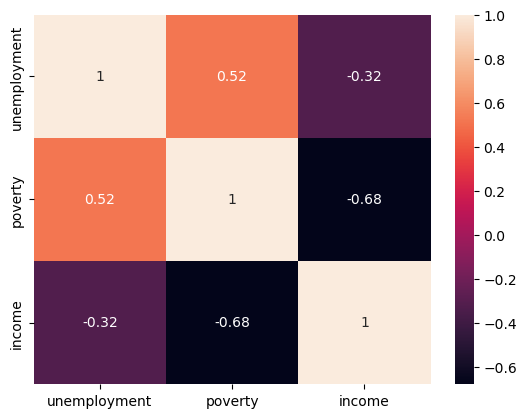

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr, annot=True)
plt.show()

In [37]:
poverty

,County,FIPS,Value (Percent),Families (Below Poverty),Rank within US (of 3143 counties)
0,"Oglala Lakota County, South Dakota",46102.0,48.8,1101.0,"3,143"
1,"Jackson County, South Dakota",46071.0,38.9,213.0,"3,142"
2,"Todd County, South Dakota",46121.0,38.4,672.0,"3,141"
4,"Dimmit County, Texas",48127.0,36.8,800.0,"3,139"
5,"Corson County, South Dakota",46031.0,35.2,290.0,"3,138"
...,...,...,...,...,...
3138,"Hinsdale County, Colorado",8053.0,0.0,0.0,1
3139,"Hooker County, Nebraska",31091.0,0.0,0.0,1
3140,"Kalawao County, Hawaii",15005.0,0.0,0.0,1
3141,"Kenedy County, Texas",48261.0,0.0,0.0,1


In [38]:
unemployment

,County,FIPS,Value (Percent),People (Unemployed),Rank within US (of 3143 counties)
0,"Quitman County, Georgia",13239.0,31.1,237.0,"3,143"
1,"Ziebach County, South Dakota",46137.0,24.2,276.0,"3,142"
2,"Corson County, South Dakota",46031.0,23.3,359.0,"3,141"
3,"Sioux County, North Dakota",38085.0,21.5,291.0,"3,140"
4,"St. Helena Parish, Louisiana",22091.0,21.3,1044.0,"3,139"
...,...,...,...,...,...
3138,"McMullen County, Texas",48311.0,0.0,0.0,1
3139,"McPherson County, Nebraska",31117.0,0.0,0.0,1
3140,"Sully County, South Dakota",46119.0,0.0,0.0,1
3141,"Terrell County, Texas",48443.0,0.0,0.0,1


In [39]:
income


,County,FIPS,Value (Dollars),Rank within US (of 3141 counties)
1,"Randolph County, Georgia",13243.0,"25,425","3,140"
2,"Jackson County, South Dakota",46071.0,"26,686","3,139"
3,"East Carroll Parish, Louisiana",22035.0,"28,321","3,138"
4,"Presidio County, Texas",48377.0,"29,014","3,137"
5,"Wolfe County, Kentucky",21237.0,"29,052","3,136"
...,...,...,...,...
3138,"San Mateo County, California",6081.0,"156,000",3
3139,"Santa Clara County, California",6085.0,"159,674",2
3140,"Loudoun County, Virginia",51107.0,"178,707",1
3141,"Esmeralda County, Nevada",32009.0,NaN,NaN


In [40]:
import pandas as pd

# Assuming your DataFrame is named 'df'
df.to_csv('fullset.csv', index=False)
